# Ensemble Means by Scenario and Threshold

This cell computes ensemble mean results across all CMIP6 model outputs for each scenario (`ssp245` and `ssp585`) and for each threshold band (`t10`, `t25`, `t50`, `t100`). The output is written as a 4-band GeoTIFF per scenario.

In [1]:
import os
import re
import numpy as np
import rasterio
from collections import defaultdict

# Paths
base_dir = "data/CMIP6_Multi_Band_Results"
ensemble_dir = os.path.join(base_dir, "ensemble_means")
os.makedirs(ensemble_dir, exist_ok=True)

# Pattern to identify model results and scenario from file names
pattern = re.compile(r"(?P<model>.+?)_ssp(?P<scenario>\d{3})_MultiThreshold\.tif$")

# Group all model files by scenario
scenario_files = defaultdict(list)
for filename in sorted(os.listdir(base_dir)):
    match = pattern.match(filename)
    if match:
        scenario = f"ssp{match.group('scenario')}"
        scenario_files[scenario].append(os.path.join(base_dir, filename))

if not scenario_files:
    raise ValueError(f"No MultiThreshold TIFF files found in {base_dir}")

# Read all files for each scenario and compute ensemble mean
for scenario, filepaths in scenario_files.items():
    print(f"Processing {scenario} with {len(filepaths)} models...")

    arrays = []
    meta = None
    for path in filepaths:
        with rasterio.open(path) as src:
            data = src.read().astype('float32')
            if meta is None:
                meta = src.meta.copy()
            else:
                if src.count != meta['count'] or src.width != meta['width'] or src.height != meta['height']:
                    raise ValueError(f"Dimension mismatch for {path}")
                if src.transform != meta['transform'] or src.crs != meta['crs']:
                    raise ValueError(f"Spatial reference mismatch for {path}")
            arrays.append(data)

    stack = np.stack(arrays, axis=0)
    ensemble = np.mean(stack, axis=0)

    # Write one ensemble file with the same 4 bands
    out_path = os.path.join(ensemble_dir, f"{scenario}_ensemble_mean_MultiThreshold.tif")
    meta.update(dtype='float32')
    with rasterio.open(out_path, 'w', **meta) as dst:
        dst.write(ensemble)

    print(f"Saved ensemble mean: {out_path}")

print("Ensemble mean generation complete.")

Processing ssp245 with 33 models...
Saved ensemble mean: data/CMIP6_Multi_Band_Results/ensemble_means/ssp245_ensemble_mean_MultiThreshold.tif
Processing ssp585 with 33 models...
Saved ensemble mean: data/CMIP6_Multi_Band_Results/ensemble_means/ssp585_ensemble_mean_MultiThreshold.tif
Ensemble mean generation complete.


# Threshold Change Visualization

This cell loads the ensemble mean TIFFs for each scenario, computes the mean change for each threshold band, and creates a comparison plot for `ssp245` and `ssp585`.

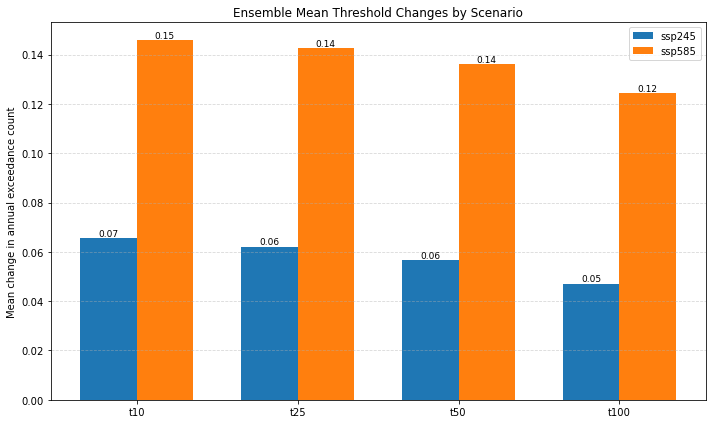

In [2]:
import glob
import matplotlib.pyplot as plt
import rasterio
import numpy as np

thresholds = ['t10', 't25', 't50', 't100']
scenario_order = ['ssp245', 'ssp585']

ensemble_dir = os.path.join(base_dir, 'ensemble_means')
ensemble_files = sorted(glob.glob(os.path.join(ensemble_dir, '*_ensemble_mean_MultiThreshold.tif')))

scenario_means = {}
for path in ensemble_files:
    scenario = os.path.basename(path).split('_')[0]
    with rasterio.open(path) as src:
        data = src.read().astype('float32')
        band_means = [np.nanmean(data[i]) for i in range(data.shape[0])]
    scenario_means[scenario] = band_means

if not scenario_means:
    raise ValueError(f"No ensemble mean TIFFs found in {ensemble_dir}")

x = np.arange(len(thresholds))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
for idx, scenario in enumerate(scenario_order):
    if scenario not in scenario_means:
        continue
    offsets = x + (idx - 0.5) * width
    ax.bar(offsets, scenario_means[scenario], width, label=scenario)

ax.set_xticks(x)
ax.set_xticklabels(thresholds)
ax.set_ylabel('Mean change in annual exceedance count')
ax.set_title('Ensemble Mean Threshold Changes by Scenario')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)

for idx, scenario in enumerate(scenario_order):
    if scenario not in scenario_means:
        continue
    offsets = x + (idx - 0.5) * width
    for xi, yi in zip(offsets, scenario_means[scenario]):
        ax.text(xi, yi, f"{yi:.2f}", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Return-Period Equivalence for Threshold Changes

This cell converts the mean change in exceedance count for each threshold into an approximate equivalent return period, using the threshold names as baseline return periods.

In [3]:
from pandas import DataFrame

baseline_returns = np.array([10.0, 25.0, 50.0, 100.0])
baseline_freq = 1.0 / baseline_returns

rows = []
for scenario in scenario_order:
    if scenario not in scenario_means:
        continue

    changes = np.array(scenario_means[scenario], dtype='float32')
    future_freq = baseline_freq + changes
    future_return = np.where(future_freq > 0, 1.0 / future_freq, np.nan)
    for threshold, change, future_r in zip(thresholds, changes, future_return):
        rows.append({
            'scenario': scenario,
            'threshold': threshold,
            'baseline_return_years': float(baseline_returns[thresholds.index(threshold)]),
            'change_count_per_year': float(change),
            'equivalent_return_years': float(future_r)
        })

report = DataFrame(rows)
report['equivalent_return_years'] = report['equivalent_return_years'].round(1)
report

,scenario,threshold,baseline_return_years,change_count_per_year,equivalent_return_years
0,ssp245,t10,10.0,0.065674,6.0
1,ssp245,t25,25.0,0.062105,9.8
2,ssp245,t50,50.0,0.056520,13.1
3,ssp245,t100,100.0,0.047127,17.5
4,ssp585,t10,10.0,0.145747,4.1
5,ssp585,t25,25.0,0.142464,5.5
6,ssp585,t50,50.0,0.136230,6.4
7,ssp585,t100,100.0,0.124282,7.4


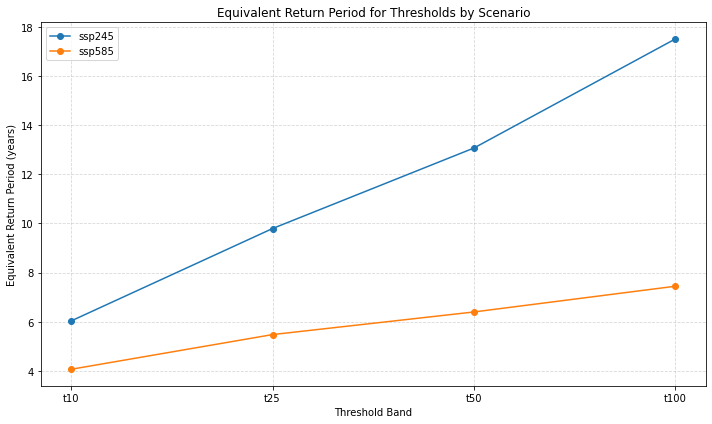

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))
for scenario in scenario_order:
    if scenario not in scenario_means:
        continue
    changes = np.array(scenario_means[scenario], dtype='float32')
    future_freq = baseline_freq + changes
    future_return = np.where(future_freq > 0, 1.0 / future_freq, np.nan)
    ax.plot(thresholds, future_return, marker='o', label=scenario)

ax.set_xlabel('Threshold Band')
ax.set_ylabel('Equivalent Return Period (years)')
ax.set_title('Equivalent Return Period for Thresholds by Scenario')
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend()
plt.tight_layout()
plt.show()

The equivalent return period is computed as `1 / (baseline_frequency + mean_change)`.
For example, if the 50-year threshold frequency increases from 0.02/year to 0.08/year, that means the future 50-year threshold behaves more like a 12.5-year event.

# Improved Presentation: Baseline vs Equivalent Return Periods

This cell creates a grouped bar chart comparing baseline return periods with their equivalent future values for each scenario and threshold.

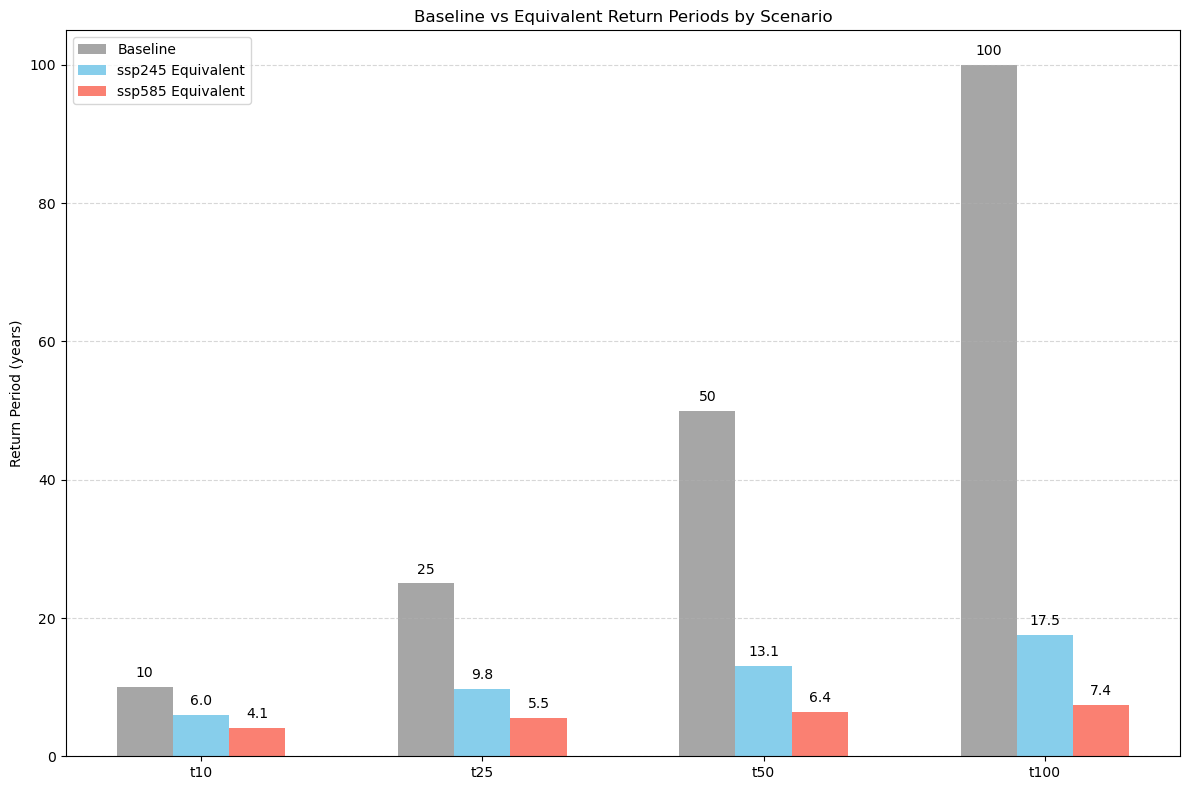

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import glob
import rasterio
import os

# Prepare data for plotting
baseline_returns = np.array([10.0, 25.0, 50.0, 100.0])
baseline_freq = 1.0 / baseline_returns
thresholds = ['t10', 't25', 't50', 't100']
scenario_order = ['ssp245', 'ssp585']

# Load scenario_means (from earlier cell)
base_dir = "data/CMIP6_Multi_Band_Results"
ensemble_dir = os.path.join(base_dir, 'ensemble_means')
ensemble_files = sorted(glob.glob(os.path.join(ensemble_dir, '*_ensemble_mean_MultiThreshold.tif')))

scenario_means = {}
for path in ensemble_files:
    scenario = os.path.basename(path).split('_')[0]
    with rasterio.open(path) as src:
        data = src.read().astype('float32')
        band_means = [np.nanmean(data[i]) for i in range(data.shape[0])]
    scenario_means[scenario] = band_means

# Compute equivalent returns as before
scenario_equivalents = {}
for scenario in scenario_order:
    if scenario not in scenario_means:
        continue
    changes = np.array(scenario_means[scenario], dtype='float32')
    future_freq = baseline_freq + changes
    future_return = np.where(future_freq > 0, 1.0 / future_freq, np.nan)
    scenario_equivalents[scenario] = future_return

# Plot grouped bars
x = np.arange(len(thresholds))
width = 0.2

fig, ax = plt.subplots(figsize=(12, 8))

# Baseline bars
ax.bar(x - width, baseline_returns, width, label='Baseline', color='gray', alpha=0.7)

# Equivalent bars for each scenario
colors = ['skyblue', 'salmon']
for idx, scenario in enumerate(scenario_order):
    if scenario in scenario_equivalents:
        ax.bar(x + idx * width, scenario_equivalents[scenario], width, label=f'{scenario} Equivalent', color=colors[idx])

ax.set_xticks(x)
ax.set_xticklabels(thresholds)
ax.set_ylabel('Return Period (years)')
ax.set_title('Baseline vs Equivalent Return Periods by Scenario')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)

# Add value labels
for i, val in enumerate(baseline_returns):
    ax.text(i - width, val + 1, f'{val:.0f}', ha='center', va='bottom')

for idx, scenario in enumerate(scenario_order):
    if scenario in scenario_equivalents:
        for i, val in enumerate(scenario_equivalents[scenario]):
            if not np.isnan(val):
                ax.text(i + idx * width, val + 1, f'{val:.1f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Southeast US Ensemble Mean Maps

This cell crops each scenario ensemble mean raster to the U.S. Southeast state borders and plots the mean ensemble values only inside those state boundaries.

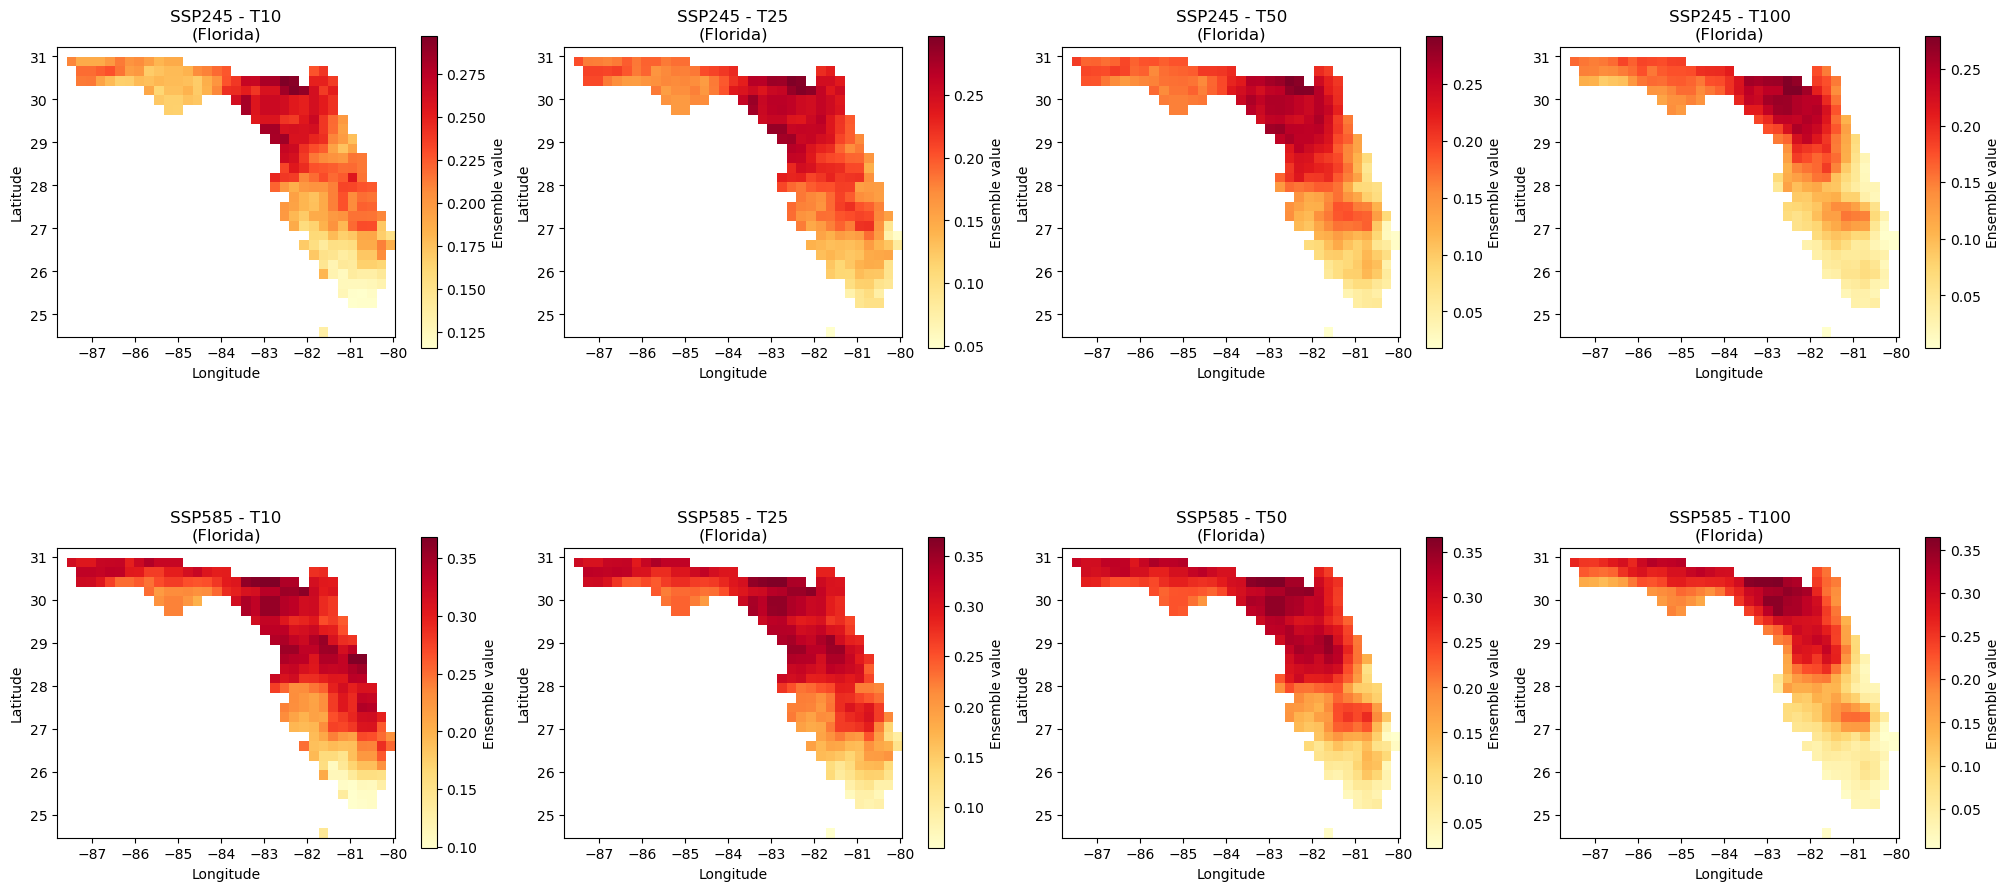

In [7]:
import os
import glob
import json
import urllib.request
import numpy as np
import matplotlib.pyplot as plt
import rasterio
from shapely.geometry import shape
from rasterio.mask import mask

base_dir = "data/CMIP6_Multi_Band_Results"
ensemble_dir = os.path.join(base_dir, "ensemble_means")
geojson_url = "https://eric.clst.org/assets/wiki/uploads/Stuff/gz_2010_us_040_00_500k.json"
state_geojson_path = os.path.join(base_dir, "us_states_500k.json")

if not os.path.exists(state_geojson_path):
    print(f"Downloading US state boundaries to {state_geojson_path} ...")
    urllib.request.urlretrieve(geojson_url, state_geojson_path)

with open(state_geojson_path, "r") as fp:
    states_geojson = json.load(fp)

state_geoms = []
for feature in states_geojson["features"]:
    name = feature["properties"].get("NAME")
    if name == "Florida":
        state_geoms.append(shape(feature["geometry"]))

if not state_geoms:
    raise ValueError("Could not find Florida in the downloaded GeoJSON.")

mask_geoms = state_geoms

scenario_files = sorted(glob.glob(os.path.join(ensemble_dir, '*_ensemble_mean_MultiThreshold.tif')))
if not scenario_files:
    raise ValueError(f"No ensemble mean TIFFs found in {ensemble_dir}")

fig, axes = plt.subplots(2, 4, figsize=(20, 10), constrained_layout=True)
axes = axes.flatten()

thresholds = ['t10', 't25', 't50', 't100']
band_idx = 0

for scenario_idx, path in enumerate(scenario_files):
    scenario = os.path.basename(path).split('_')[0]
    with rasterio.open(path) as src:
        masked_data, out_transform = mask(src, mask_geoms, crop=True, nodata=np.nan)

    xmin = out_transform[2]
    xmax = out_transform[2] + out_transform[0] * masked_data.shape[2]
    ymax = out_transform[5]
    ymin = out_transform[5] + out_transform[4] * masked_data.shape[1]
    extent = (xmin, xmax, ymin, ymax)

    for band_num in range(masked_data.shape[0]):
        ax = axes[scenario_idx * 4 + band_num]
        band_data = masked_data[band_num, :, :]
        
        im = ax.imshow(band_data, cmap='YlOrRd', origin='upper', extent=extent)
        ax.set_title(f"{scenario.upper()} - {thresholds[band_num].upper()}\n(Florida)")
        ax.set_xlabel('Longitude')
        ax.set_ylabel('Latitude')
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Ensemble value')

plt.show()

In [8]:
import pandas as pd

# Extract pixel data and create CSV
csv_data = []
thresholds = ['t10', 't25', 't50', 't100']

for scenario_idx, path in enumerate(scenario_files):
    scenario = os.path.basename(path).split('_')[0]
    with rasterio.open(path) as src:
        masked_data, out_transform = mask(src, mask_geoms, crop=True, nodata=np.nan)

    xmin = out_transform[2]
    ymax = out_transform[5]
    pixel_width = out_transform[0]
    pixel_height = out_transform[4]

    # Extract coordinates and values for each band
    for band_num in range(masked_data.shape[0]):
        band_data = masked_data[band_num, :, :]
        
        # Create coordinate grids
        rows, cols = np.where(~np.isnan(band_data))
        for row, col in zip(rows, cols):
            lon = xmin + col * pixel_width
            lat = ymax + row * pixel_height
            value = band_data[row, col]
            
            csv_data.append({
                'scenario': scenario,
                'threshold': thresholds[band_num],
                'longitude': lon,
                'latitude': lat,
                'frequency_change_per_year': value
            })

# Create DataFrame and save to CSV
df = pd.DataFrame(csv_data)
csv_path = os.path.join(base_dir, 'florida_ensemble_frequency_changes.csv')
df.to_csv(csv_path, index=False)
print(f"CSV saved to: {csv_path}")
print(f"Total pixels: {len(df)}")
df.head(10)

CSV saved to: data/CMIP6_Multi_Band_Results/florida_ensemble_frequency_changes.csv
Total pixels: 2184


,scenario,threshold,longitude,latitude,frequency_change_per_year
0,ssp245,t10,-87.585740,30.991877,0.209091
1,ssp245,t10,-87.361161,30.991877,0.187879
2,ssp245,t10,-87.136583,30.991877,0.187879
3,ssp245,t10,-86.912004,30.991877,0.187879
4,ssp245,t10,-86.687425,30.991877,0.198990
5,ssp245,t10,-86.462846,30.991877,0.213131
6,ssp245,t10,-86.238267,30.991877,0.202020
7,ssp245,t10,-86.013688,30.991877,0.206061
8,ssp245,t10,-85.789110,30.991877,0.195960
9,ssp245,t10,-85.564531,30.991877,0.181818
